# Anemia Prediction from Preprocessed Nail Images — MobileNetV3 MacBook-Lite v5

This is the most updated MacBook-safe notebook version. It keeps the no-leakage pipeline, uses a lightweight frozen MobileNetV3-Small backbone, and replaces the test precision-recall curve with an anemia-only classification report heatmap.

## What this notebook does

- Takes already-preprocessed nail images and clinical/demographic CSV files.
- Matches image files to patient/record metadata.
- Splits data by `record_id` before image expansion to avoid data leakage.
- Trains a lightweight image + demographics fusion model.
- Predicts both:
  - HGB regression value.
  - anemia / non-anemia classification.
- Generates performance figures and CSV reports.

## Full update history included in this version

### Original RegNet no-leakage version
- Built a RegNet-400MF-style anemia prediction notebook based on the provided method architecture.
- Added record/patient-level split before image expansion.
- Added optional MD5 image-hash leakage check.
- Used color eye images only by default, excluding black-and-white image columns.
- Added HGB/age cleaning and likely HGB/HCT swap correction.
- Added image + demographics fusion.
- Removed ITA skin-tone input from demographics preprocessing.
- Added regression head for HGB prediction and classification head for anemia prediction.
- Added weighted sampling using HGB bins and minority anemia class weighting.
- Added performance plots and subgroup reports.

### Mac/Jupyter DataLoader fix
- Set `NUM_WORKERS = 0` to avoid macOS multiprocessing errors with notebook-defined datasets.
- Set `PIN_MEMORY = False` unless CUDA is used.
- Added safer Apple Silicon / MPS device handling.

### NaN-safe training fix
- Added checks for NaN/Inf in model inputs, losses, predictions, and parameters.
- Lowered learning rates.
- Added safer small-batch normalization behavior.
- Added debugging outputs for non-finite predictions.

### MacBook-lite conversion
- Replaced RegNet-400MF with MobileNetV3-Small.
- Frozen pretrained image backbone by default.
- Reduced image size to `IMAGE_SIZE = 128`.
- Reduced batch size to `BATCH_SIZE = 4`.
- Added cooling pause between epochs.
- Kept the model light enough for MacBook debugging and baseline training.

### Reviewed v2 fixes
- Fixed Hispanic/non-Hispanic grouping bug where `NON-HISPANIC` was incorrectly detected as Hispanic.
- Kept race/ethnicity out of model inputs; race/ethnicity are used only for subgroup/fairness-style reporting.
- Added validation-only threshold selection for anemia classification, so the test set is not used to choose the threshold.

### Reviewed v3 fixes
- Added patient-balanced sampling so records with many nail crops do not dominate training.
- Added same-image-path safety check to catch cases where one physical image path maps to multiple `record_id`s.

### Reviewed v4/v5 visualization update
- Removed the test precision-recall curve from the output plots.
- Added anemia-only classification report heatmap like the requested format:
  - precision
  - recall
  - F1-score
- Saves:
  - `test_classification_report_anemia_only_heatmap.png`
  - `test_classification_report_anemia_only.csv`
- Keeps useful regression/classification figures:
  - true-vs-predicted HGB plot
  - residual histogram
  - confusion matrix
  - ROC curve

## Recommended use

Use this notebook for MacBook-safe debugging and baseline results. For final stronger training, use the same no-leakage logic on Colab, Kaggle, or a lab GPU machine with a heavier model or unfrozen backbone.


### v4 update: classification-report heatmap instead of precision-recall curve

This version keeps the MacBook-lite MobileNetV3 setup and v3 patient-balanced training, then changes the final performance visualization:

- Removes the test-set precision-recall curve figure.
- Adds an anemia-only classification report heatmap showing precision, recall, and F1-score.
- Keeps the ROC curve, confusion matrix, regression plots, and no-leakage record-level split.


## 0. Setup

Edit `IMAGE_ROOT` to the folder containing your preprocessed nail images.

For MacBook safety, the default settings are intentionally light. The goal is to finish a clean no-leakage run first, not to squeeze maximum accuracy from the laptop.


In [1]:
from pathlib import Path
import os, re, math, json, random, hashlib, warnings, time
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd

# ====== EDIT THIS ======
IMAGE_ROOT = Path('/Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/pre_process/glare/usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output/safe_for_training_png')  # <-- change this

FILE_DIRECTORY_CSV = Path('/Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/FileDirectory.csv')
LAB_CSV = Path('/Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/PredictingAnemiaInCo-CJStudyData_DATA_2023-07-12_0653.csv')
DEMOGRAPHICS_CSV = Path('/Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/Race and gender file 070425.csv')

# If running outside your Mac path, change these paths, for example:
# FILE_DIRECTORY_CSV = Path('FileDirectory.csv')
# LAB_CSV = Path('PredictingAnemiaInCo-CJStudyData_DATA_2023-07-12_0653.csv')
# DEMOGRAPHICS_CSV = Path('Race and gender file 070425.csv')

OUT_DIR = Path('/Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/all_usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output_mobilenetv3_lite_outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Use only original color image fields by default. This excludes eyeimage1bw, eyeimage2bw, etc.
KEEP_FIELD_REGEX = r'^eyeimage[1-5]$'

# Data split. Splitting is done by patient/record_id, not by image.
TEST_SIZE = 0.10
VAL_SIZE = 0.10
HGB_BINS = 8

# Demographic features.
# Default: race/ethnicity are used for subgroup reports, not as model inputs.
INCLUDE_RACE_IN_MODEL = False
INCLUDE_ETHNICITY_IN_MODEL = False

# Leakage checks.
# Patient-level leakage check always runs later.
# Hash check catches exact duplicate image files across splits, but it can be slow/heaty on Mac.
# Set True once for a final verification run.
RUN_HASH_LEAKAGE_CHECK = False

# =========================
# MacBook Lite training mode
# =========================
MODEL_NAME = 'mobilenet_v3_small_lite'
PRETRAINED_BACKBONE = True

# Let MPS handle the frozen feature extraction. If it still gets too hot or unstable, set FORCE_CPU=True.
FORCE_CPU = False
PREFER_MPS = True

# Reduce CPU pressure. Safe values: 1 or 2.
MAC_CPU_THREADS = 2

# Smaller images and smaller batches reduce heat a lot.
IMAGE_SIZE = 128
BATCH_SIZE = 4
NUM_WORKERS = 0
PIN_MEMORY = False

# Keep this small for your laptop. Increase only on Colab/lab GPU.
EPOCHS = 5

# Important: keep the backbone frozen on the MacBook.
# This trains only the small demographics/fusion/regression/classification heads.
FREEZE_BACKBONE_EPOCHS = 999

LR_HEAD = 1e-4
LR_BACKBONE = 1e-7  # unused unless you intentionally unfreeze later
WEIGHT_DECAY = 1e-4
REG_LOSS_WEIGHT = 1.0
CLS_LOSS_WEIGHT = 0.5
PATIENCE = 3
MINORITY_CLASS_MULTIPLIER = 2.0

# Heat-control helpers.
# Leave MAX_TRAIN_BATCHES_PER_EPOCH=None for a real full-data run.
# For a very fast smoke test, set MAX_TRAIN_BATCHES_PER_EPOCH=50.
MAX_TRAIN_BATCHES_PER_EPOCH = None
SLEEP_BETWEEN_EPOCHS_SEC = 10

# Classification threshold.
# During final evaluation, choose the anemia probability threshold using validation records only.
# Good options: 'balanced_accuracy', 'f1', or 'recall_at_precision_0.70'.
THRESHOLD_TUNING_METRIC = 'balanced_accuracy'


print('Output folder:', OUT_DIR.resolve())
print('MacBook Lite mode:')
print('  MODEL_NAME =', MODEL_NAME)
print('  IMAGE_SIZE =', IMAGE_SIZE)
print('  BATCH_SIZE =', BATCH_SIZE)
print('  EPOCHS =', EPOCHS)
print('  FREEZE_BACKBONE_EPOCHS =', FREEZE_BACKBONE_EPOCHS)
print('  RUN_HASH_LEAKAGE_CHECK =', RUN_HASH_LEAKAGE_CHECK)


Output folder: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/all_usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output_mobilenetv3_lite_outputs
MacBook Lite mode:
  MODEL_NAME = mobilenet_v3_small_lite
  IMAGE_SIZE = 128
  BATCH_SIZE = 4
  EPOCHS = 5
  FREEZE_BACKBONE_EPOCHS = 999
  RUN_HASH_LEAKAGE_CHECK = False


## 1. Load and inspect the attached CSV files

This cell checks the real columns and basic shape of the uploaded files before model building.


In [2]:

for p in [FILE_DIRECTORY_CSV, LAB_CSV, DEMOGRAPHICS_CSV]:
    if not p.exists():
        raise FileNotFoundError(f'Missing file: {p}. Please update the path in the setup cell.')

filedir_raw = pd.read_csv(FILE_DIRECTORY_CSV)
lab_raw = pd.read_csv(LAB_CSV)
demo_raw = pd.read_csv(DEMOGRAPHICS_CSV)

print('FileDirectory:', filedir_raw.shape)
display(filedir_raw.head())
print('FileDirectory columns:', filedir_raw.columns.tolist())
print('\nLab / HGB:', lab_raw.shape)
display(lab_raw.head())
print('Lab columns:', lab_raw.columns.tolist())
print('\nRace/Gender:', demo_raw.shape)
display(demo_raw.head())
print('Demographics columns:', demo_raw.columns.tolist())

summary = {
    'file_directory_rows': len(filedir_raw),
    'file_directory_records': int(filedir_raw['record'].nunique()) if 'record' in filedir_raw else None,
    'lab_rows': len(lab_raw),
    'lab_records': int(lab_raw['record_id'].nunique()) if 'record_id' in lab_raw else None,
    'demographics_rows': len(demo_raw),
    'demographics_records': int(demo_raw['Record_ID'].nunique()) if 'Record_ID' in demo_raw else None,
}
print(json.dumps(summary, indent=2))


FileDirectory: (8929, 10)


,project_id,event_id,record,field_name,value,doc_id,stored_name,mime_type,doc_size,stored_date
0,2625,14552,1,eyeimage1,120327,120327,20210604133544_pid2625_CqekU8.jpg,image/jpeg,1658415.0,6/4/2021 13:35
1,2625,14552,1,eyeimage2,120328,120328,20210604133615_pid2625_eEm3I5.jpg,image/jpeg,1414785.0,6/4/2021 13:36
2,2625,14552,1,eyeimage4,120330,120330,20210604133710_pid2625_iDVvJ9.jpg,image/jpeg,1152846.0,6/4/2021 13:37
3,2625,14552,2,eyeimage1,120481,120481,20210607132740_pid2625_7HAkYv.jpg,image/jpeg,1079877.0,6/7/2021 13:27
4,2625,14552,2,eyeimage2,120482,120482,20210607132821_pid2625_PNLUFA.jpg,image/jpeg,1022276.0,6/7/2021 13:28


FileDirectory columns: ['project_id', 'event_id', 'record', 'field_name', 'value', 'doc_id', 'stored_name', 'mime_type', 'doc_size', 'stored_date']

Lab / HGB: (1151, 5)


,record_id,hct,hgb,age,race
0,1,39.1,13.1,21,NaN
1,2,43.6,14.6,33,NaN
2,3,41.7,14.2,48,NaN
3,4,39.1,13.1,31,NaN
4,5,37.2,11.8,79,NaN


Lab columns: ['record_id', 'hct', 'hgb', 'age', 'race']

Race/Gender: (1493, 4)


,Record_ID,sex,race,ethnicity
0,1,F,WHITE,Non-Hispanic
1,2,M,ASIAN - CHINESE,Non-Hispanic
2,3,M,WHITE,Non-Hispanic
3,4,F,WHITE - OTHER EUROPEAN,Non-Hispanic
4,5,F,BLACK/AFRICAN AMERICAN,Non-Hispanic


Demographics columns: ['Record_ID', 'sex', 'race', 'ethnicity']
{
  "file_directory_rows": 8929,
  "file_directory_records": 1053,
  "lab_rows": 1151,
  "lab_records": 1151,
  "demographics_rows": 1493,
  "demographics_records": 1493
}


## 2. Clean HGB, age, sex, race, and ethnicity

Important cleaning choices:

- Converts numeric fields safely.
- Fixes likely swapped `hgb` and `hct` values when `hgb` is impossibly high and `hct` looks like a plausible HGB value.
- Keeps severe anemia values such as HGB around 3.8, but removes impossible values above 20.
- Sets invalid ages to missing, then later imputes age using the **training-set median only**.


In [3]:

def safe_float_series(s: pd.Series) -> pd.Series:
    # Convert mostly-numeric strings to float. Ambiguous values become NaN.
    x = s.astype(str).str.strip().str.replace(',', '.', regex=False)
    # Keep only strings that look like one valid number.
    ok = x.str.fullmatch(r'[+-]?(\d+(\.\d*)?|\.\d+)')
    out = pd.Series(np.nan, index=s.index, dtype='float64')
    out.loc[ok.fillna(False)] = pd.to_numeric(x.loc[ok.fillna(False)], errors='coerce')
    return out

lab = lab_raw.copy()
lab = lab.rename(columns={'record_id': 'record_id'})
lab['record_id'] = pd.to_numeric(lab['record_id'], errors='coerce').astype('Int64')
lab['hgb_num_raw'] = safe_float_series(lab['hgb'])
lab['hct_num_raw'] = safe_float_series(lab['hct'])
lab['age_num_raw'] = safe_float_series(lab['age'])

# Fix likely hgb/hct swap: hgb > 22 is not physiologically plausible for this context,
# while hct between 5 and 20 can plausibly be an HGB value.
swap_mask = (lab['hgb_num_raw'] > 22) & (lab['hct_num_raw'].between(5, 20))
lab['hgb_num'] = lab['hgb_num_raw'].where(~swap_mask, lab['hct_num_raw'])
lab['hct_num'] = lab['hct_num_raw'].where(~swap_mask, lab['hgb_num_raw'])
lab['hgb_hct_swapped'] = swap_mask

# Physiologic filters.
lab.loc[~lab['hgb_num'].between(3.0, 20.0), 'hgb_num'] = np.nan
lab['age_num'] = lab['age_num_raw']
lab.loc[~lab['age_num'].between(0, 120), 'age_num'] = np.nan

# Demographics.
demo = demo_raw.copy().rename(columns={'Record_ID': 'record_id'})
demo['record_id'] = pd.to_numeric(demo['record_id'], errors='coerce').astype('Int64')

def normalize_sex(x):
    if pd.isna(x):
        return 'Not Sure'
    x = str(x).strip().upper()
    if x in ['F', 'FEMALE', 'WOMAN']:
        return 'Female'
    if x in ['M', 'MALE', 'MAN']:
        return 'Male'
    return 'Not Sure'

def clean_text(x, default='Unknown'):
    if pd.isna(x):
        return default
    x = str(x).strip()
    if x == '' or x.lower() in ['nan', 'none', 'unknown/not specified', 'unable to obtain']:
        return default
    return x.upper()

def simplify_race(row):
    race = clean_text(row.get('race', 'Unknown'))
    eth = clean_text(row.get('ethnicity', 'Unknown'))

    # IMPORTANT:
    # Do NOT use `"HISPANIC" in eth` because "NON-HISPANIC" also contains
    # the substring "HISPANIC". That bug would incorrectly convert almost
    # everyone into Hispanic/Latino and ruin subgroup analysis.
    is_hispanic_eth = eth in ['HISPANIC', 'HISPANIC/LATINO', 'LATINO', 'LATINA', 'LATINX']
    is_hispanic_race = ('LATINO' in race) or ('LATINA' in race) or (race == 'HISPANIC')
    if is_hispanic_eth or is_hispanic_race:
        return 'Hispanic/Latino'

    if 'BLACK' in race or 'AFRICAN' in race or 'HAITIAN' in race or 'CAPE VERDEAN' in race:
        return 'Black'
    if 'ASIAN' in race or 'CHINESE' in race or 'FILIPINO' in race or 'INDIAN' in race:
        return 'Asian'
    if 'WHITE' in race or 'EUROPEAN' in race or 'PORTUGUESE' in race or 'RUSSIAN' in race:
        return 'White'
    if race == 'Unknown':
        return 'Unknown'
    return 'Other'

demo['sex_clean'] = demo['sex'].apply(normalize_sex)
demo['race_clean'] = demo['race'].apply(clean_text)
demo['ethnicity_clean'] = demo['ethnicity'].apply(clean_text)
demo['race_group'] = demo.apply(simplify_race, axis=1)

print('Likely HGB/HCT swapped rows fixed:', int(lab['hgb_hct_swapped'].sum()))
print('Valid HGB rows:', int(lab['hgb_num'].notna().sum()), '/', len(lab))
print('Invalid age rows set to NaN:', int(lab['age_num'].isna().sum()))
print('\nSex counts:')
print(demo['sex_clean'].value_counts(dropna=False))
print('\nRace-group counts:')
print(demo['race_group'].value_counts(dropna=False))

cleaning_report = lab.loc[
    lab['hgb_num'].isna() | lab['age_num'].isna() | lab['hgb_hct_swapped'],
    ['record_id', 'hct', 'hgb', 'age', 'hgb_num_raw', 'hct_num_raw', 'hgb_num', 'age_num', 'hgb_hct_swapped']
]
cleaning_report.to_csv(OUT_DIR / 'cleaning_report_suspicious_rows.csv', index=False)
print('Saved:', OUT_DIR / 'cleaning_report_suspicious_rows.csv')
display(cleaning_report.head(20))


Likely HGB/HCT swapped rows fixed: 2
Valid HGB rows: 1145 / 1151
Invalid age rows set to NaN: 8

Sex counts:
sex_clean
Female      881
Male        610
Not Sure      2
Name: count, dtype: int64

Race-group counts:
race_group
White              947
Black              307
Hispanic/Latino    133
Asian               50
Other               42
Unknown             14
Name: count, dtype: int64
Saved: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/all_usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output_mobilenetv3_lite_outputs/cleaning_report_suspicious_rows.csv


,record_id,hct,hgb,age,hgb_num_raw,hct_num_raw,hgb_num,age_num,hgb_hct_swapped
121,122,12.5,39.1,91,39.1,12.5,12.5,91.0,True
122,123,NaN,NaN,56,NaN,NaN,NaN,56.0,False
192,193,32.8,10.6,6e,10.6,32.8,10.6,NaN,False
228,229,46.6,16.0,3433841,16.0,46.6,16.0,NaN,False
258,259,29.7,9.1,2148540,9.1,29.7,9.1,NaN,False
328,329,NaN,NaN,29,NaN,NaN,NaN,29.0,False
408,409,37.3,12.2,NaN,12.2,37.3,12.2,NaN,False
482,483,45.9,14.4,NaN,14.4,45.9,14.4,NaN,False
485,486,Pnd,Pnd,67,NaN,NaN,NaN,67.0,False
502,503,NaN,NaN,72,NaN,NaN,NaN,72.0,False


## 3. Build image-level metadata from FileDirectory + labels + demographics

The model should learn from nail images only. By default this cell keeps `eyeimage1` to `eyeimage5` and excludes `eyeimage1bw`, etc., because black-and-white images can destroy color information that matters for HGB prediction.


In [4]:

filedir = filedir_raw.copy()
required_cols = ['record', 'field_name', 'stored_name', 'mime_type']
missing = [c for c in required_cols if c not in filedir.columns]
if missing:
    raise ValueError(f'FileDirectory.csv is missing required columns: {missing}')

filedir['record_id'] = pd.to_numeric(filedir['record'], errors='coerce').astype('Int64')
filedir['field_name'] = filedir['field_name'].astype(str)
filedir['stored_name'] = filedir['stored_name'].astype(str)
filedir['is_kept_field'] = filedir['field_name'].str.match(KEEP_FIELD_REGEX, na=False)
filedir['is_image_mime'] = filedir['mime_type'].astype(str).str.startswith('image/', na=False)
filedir = filedir[filedir['is_kept_field'] & filedir['is_image_mime']].copy()

meta = (
    filedir
    .merge(lab[['record_id', 'hgb_num', 'age_num', 'hgb_hct_swapped']], on='record_id', how='left')
    .merge(demo[['record_id', 'sex_clean', 'race_clean', 'ethnicity_clean', 'race_group']], on='record_id', how='left')
)
meta['sex_clean'] = meta['sex_clean'].fillna('Not Sure')
meta['race_clean'] = meta['race_clean'].fillna('Unknown')
meta['ethnicity_clean'] = meta['ethnicity_clean'].fillna('Unknown')
meta['race_group'] = meta['race_group'].fillna('Unknown')

# Keep only rows with valid HGB. Age can be missing and will be imputed later from train only.
meta = meta[meta['hgb_num'].notna()].copy()

print('Image metadata rows after filtering:', meta.shape)
print('Unique records:', meta['record_id'].nunique())
print('Fields kept:')
print(meta['field_name'].value_counts())
display(meta.head())

meta.to_csv(OUT_DIR / 'metadata_before_path_resolution.csv', index=False)
print('Saved:', OUT_DIR / 'metadata_before_path_resolution.csv')


Image metadata rows after filtering: (4948, 20)
Unique records: 1047
Fields kept:
field_name
eyeimage1    1041
eyeimage4    1037
eyeimage2    1036
eyeimage5    1004
eyeimage3     830
Name: count, dtype: int64


,project_id,event_id,record,field_name,value,doc_id,stored_name,mime_type,doc_size,stored_date,record_id,is_kept_field,is_image_mime,hgb_num,age_num,hgb_hct_swapped,sex_clean,race_clean,ethnicity_clean,race_group
0,2625,14552,1,eyeimage1,120327,120327,20210604133544_pid2625_CqekU8.jpg,image/jpeg,1658415.0,6/4/2021 13:35,1,True,True,13.1,21.0,False,Female,WHITE,NON-HISPANIC,White
1,2625,14552,1,eyeimage2,120328,120328,20210604133615_pid2625_eEm3I5.jpg,image/jpeg,1414785.0,6/4/2021 13:36,1,True,True,13.1,21.0,False,Female,WHITE,NON-HISPANIC,White
2,2625,14552,1,eyeimage4,120330,120330,20210604133710_pid2625_iDVvJ9.jpg,image/jpeg,1152846.0,6/4/2021 13:37,1,True,True,13.1,21.0,False,Female,WHITE,NON-HISPANIC,White
3,2625,14552,2,eyeimage1,120481,120481,20210607132740_pid2625_7HAkYv.jpg,image/jpeg,1079877.0,6/7/2021 13:27,2,True,True,14.6,33.0,False,Male,ASIAN - CHINESE,NON-HISPANIC,Asian
4,2625,14552,2,eyeimage2,120482,120482,20210607132821_pid2625_PNLUFA.jpg,image/jpeg,1022276.0,6/7/2021 13:28,2,True,True,14.6,33.0,False,Male,ASIAN - CHINESE,NON-HISPANIC,Asian


Saved: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/all_usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output_mobilenetv3_lite_outputs/metadata_before_path_resolution.csv


## 4. Resolve preprocessed image paths

This cell links each row in `FileDirectory.csv` to your actual preprocessed nail images.

It supports these filename cases:

- Exact same filename, e.g. `20210604133544_pid2625_CqekU8.jpg`
- Same stem with another extension, e.g. `20210604133544_pid2625_CqekU8.png`
- Crop filenames that contain the original stem, e.g. `20210604133544_pid2625_CqekU8_nail_0.png`

If a single original image produced multiple nail crops, all matched crops are included as separate training samples.


In [5]:

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}

if not IMAGE_ROOT.exists():
    raise FileNotFoundError(
        f'IMAGE_ROOT does not exist: {IMAGE_ROOT}\n'
        'Please edit IMAGE_ROOT in the setup cell to your preprocessed nail-image folder.'
    )

all_files = [p for p in IMAGE_ROOT.rglob('*') if p.is_file() and p.suffix.lower() in IMG_EXTS]
print('Found image files under IMAGE_ROOT:', len(all_files))
if len(all_files) == 0:
    raise FileNotFoundError(f'No image files found under {IMAGE_ROOT}')

# Build fast exact indexes.
name_index: Dict[str, List[Path]] = {}
stem_index: Dict[str, List[Path]] = {}
lower_name_pairs = []
for p in all_files:
    lname = p.name.lower()
    lstem = p.stem.lower()
    name_index.setdefault(lname, []).append(p)
    stem_index.setdefault(lstem, []).append(p)
    lower_name_pairs.append((lname, p))

def resolve_one(stored_name: str) -> List[Path]:
    sn = str(stored_name)
    base = Path(sn).name
    stem = Path(base).stem.lower()
    lname = base.lower()
    found = []
    # 1) exact filename
    found.extend(name_index.get(lname, []))
    # 2) exact stem with any extension
    found.extend(stem_index.get(stem, []))
    # 3) cropped filenames containing original stem
    if not found and stem:
        found.extend([p for ln, p in lower_name_pairs if stem in ln])
    # Remove duplicates while preserving order.
    unique = []
    seen = set()
    for p in found:
        rp = str(p.resolve())
        if rp not in seen:
            seen.add(rp)
            unique.append(p)
    return unique

expanded_rows = []
for _, row in meta.iterrows():
    matches = resolve_one(row['stored_name'])
    for p in matches:
        d = row.to_dict()
        d['image_path'] = str(p)
        d['matched_filename'] = p.name
        expanded_rows.append(d)

image_df = pd.DataFrame(expanded_rows)
print('Rows after resolving image paths:', image_df.shape)
if len(image_df) == 0:
    sample_names = meta['stored_name'].head(10).tolist()
    raise RuntimeError(
        'No FileDirectory stored_name matched files under IMAGE_ROOT.\n'
        f'Sample stored_name values: {sample_names}\n'
        'Your preprocessed filenames may have lost the original stem. Rename them or provide a mapping CSV.'
    )

print('Unique records with matched images:', image_df['record_id'].nunique())

# Safety check: one physical image path should not be assigned to multiple record_ids.
# This catches filename/stem matching mistakes that could silently mix patients.
path_record_counts = image_df.groupby('image_path')['record_id'].nunique()
bad_paths = path_record_counts[path_record_counts > 1]
if len(bad_paths):
    bad = image_df[image_df['image_path'].isin(bad_paths.index)].sort_values(['image_path', 'record_id'])
    bad.to_csv(OUT_DIR / 'BAD_same_image_path_multiple_records.csv', index=False)
    display(bad.head(50))
    raise RuntimeError(
        'Same image file path matched multiple record_ids. '
        f'Saved report to {OUT_DIR / "BAD_same_image_path_multiple_records.csv"}'
    )
else:
    print('PASS: no image file path is shared by multiple records.')

print('Rows per record:')
print(image_df.groupby('record_id').size().describe())

audit_missing = meta[~meta['stored_name'].isin(set(image_df['stored_name']))].copy()
audit_missing.to_csv(OUT_DIR / 'path_resolution_missing_original_images.csv', index=False)
image_df.to_csv(OUT_DIR / 'metadata_with_resolved_image_paths.csv', index=False)
print('Saved:', OUT_DIR / 'metadata_with_resolved_image_paths.csv')
print('Saved:', OUT_DIR / 'path_resolution_missing_original_images.csv')
display(image_df.head())


Found image files under IMAGE_ROOT: 3448
Rows after resolving image paths: (3422, 22)
Unique records with matched images: 830
PASS: no image file path is shared by multiple records.
Rows per record:
count    830.000000
mean       4.122892
std        0.746092
min        1.000000
25%        4.000000
50%        4.000000
75%        5.000000
max        8.000000
dtype: float64
Saved: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/all_usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output_mobilenetv3_lite_outputs/metadata_with_resolved_image_paths.csv
Saved: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/all_usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output_mobilenetv3_lite_outputs/path_resolution_missing_original_images.csv


,project_id,event_id,record,field_name,value,doc_id,stored_name,mime_type,doc_size,stored_date,...,is_image_mime,hgb_num,age_num,hgb_hct_swapped,sex_clean,race_clean,ethnicity_clean,race_group,image_path,matched_filename
0,2625,14552,2,eyeimage5,120485,120485,20210607132915_pid2625_eowkBq.jpg,image/jpeg,1507505.0,6/7/2021 13:29,...,True,14.6,33.0,False,Male,ASIAN - CHINESE,NON-HISPANIC,Asian,/Users/williamtsai/Desktop/NTHU 3.2/special to...,20210607132915_pid2625_eowkBq_nail_02.png
1,2625,14552,2,eyeimage5,120485,120485,20210607132915_pid2625_eowkBq.jpg,image/jpeg,1507505.0,6/7/2021 13:29,...,True,14.6,33.0,False,Male,ASIAN - CHINESE,NON-HISPANIC,Asian,/Users/williamtsai/Desktop/NTHU 3.2/special to...,20210607132915_pid2625_eowkBq_nail_03.png
2,2625,14552,2,eyeimage5,120485,120485,20210607132915_pid2625_eowkBq.jpg,image/jpeg,1507505.0,6/7/2021 13:29,...,True,14.6,33.0,False,Male,ASIAN - CHINESE,NON-HISPANIC,Asian,/Users/williamtsai/Desktop/NTHU 3.2/special to...,20210607132915_pid2625_eowkBq_nail_01.png
3,2625,14552,2,eyeimage5,120485,120485,20210607132915_pid2625_eowkBq.jpg,image/jpeg,1507505.0,6/7/2021 13:29,...,True,14.6,33.0,False,Male,ASIAN - CHINESE,NON-HISPANIC,Asian,/Users/williamtsai/Desktop/NTHU 3.2/special to...,20210607132915_pid2625_eowkBq_nail_04.png
4,2625,14552,3,eyeimage5,120494,120494,20210607135137_pid2625_5Ae83W.jpg,image/jpeg,1831450.0,6/7/2021 13:51,...,True,14.2,48.0,False,Male,WHITE,NON-HISPANIC,White,/Users/williamtsai/Desktop/NTHU 3.2/special to...,20210607135137_pid2625_5Ae83W_nail_04.png


## 5. Create anemia label and HGB bins

For classification, this notebook uses common adult HGB thresholds:

- Male: anemia if HGB < 13.0 g/dL
- Female: anemia if HGB < 12.0 g/dL
- Not sure / missing sex: anemia if HGB < 12.5 g/dL

For stratification and weighted sampling, HGB is converted into 8 bins at the **record level**.


In [6]:

def anemia_from_hgb_sex(hgb, sex):
    sex = str(sex)
    if sex == 'Male':
        return int(hgb < 13.0)
    if sex == 'Female':
        return int(hgb < 12.0)
    return int(hgb < 12.5)

record_df = (
    image_df
    .sort_values(['record_id', 'image_path'])
    .groupby('record_id', as_index=False)
    .agg({
        'hgb_num': 'first',
        'age_num': 'first',
        'sex_clean': 'first',
        'race_clean': 'first',
        'ethnicity_clean': 'first',
        'race_group': 'first',
        'image_path': 'count',
    })
    .rename(columns={'image_path': 'n_images'})
)
record_df['anemia_label'] = record_df.apply(lambda r: anemia_from_hgb_sex(r['hgb_num'], r['sex_clean']), axis=1)
record_df['hgb_bin'] = pd.qcut(record_df['hgb_num'], q=HGB_BINS, labels=False, duplicates='drop')
record_df['hgb_bin'] = record_df['hgb_bin'].astype(int)

print('Record-level dataset:', record_df.shape)
print('Anemia class counts:')
print(record_df['anemia_label'].value_counts())
print('\nHGB bin counts:')
print(record_df['hgb_bin'].value_counts().sort_index())
print('\nHGB summary:')
display(record_df['hgb_num'].describe())

record_df.to_csv(OUT_DIR / 'record_level_clean_dataset.csv', index=False)
print('Saved:', OUT_DIR / 'record_level_clean_dataset.csv')


Record-level dataset: (830, 10)
Anemia class counts:
anemia_label
1    476
0    354
Name: count, dtype: int64

HGB bin counts:
hgb_bin
0    110
1    104
2    102
3    100
4    112
5     94
6    111
7     97
Name: count, dtype: int64

HGB summary:


count    830.000000
mean      11.542313
std        2.655018
min        4.600000
25%        9.400000
50%       11.800000
75%       13.575000
max       18.900000
Name: hgb_num, dtype: float64

Saved: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/all_usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output_mobilenetv3_lite_outputs/record_level_clean_dataset.csv


## 6. Patient-level split with leakage checks

This is the core anti-leakage step.

Splitting happens on `record_id`, not on images. After splitting, the split label is copied back to all image rows from the same record.


In [7]:

from sklearn.model_selection import train_test_split

records = record_df.copy()

# Split test first.
try:
    trainval_records, test_records = train_test_split(
        records,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=records['hgb_bin']
    )
except ValueError as e:
    print('HGB-bin stratification failed; falling back to anemia stratification:', e)
    trainval_records, test_records = train_test_split(
        records,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=records['anemia_label']
    )

# Split validation from remaining records. Convert whole-dataset VAL_SIZE into fraction of trainval.
val_fraction_of_trainval = VAL_SIZE / (1.0 - TEST_SIZE)
try:
    train_records, val_records = train_test_split(
        trainval_records,
        test_size=val_fraction_of_trainval,
        random_state=SEED,
        stratify=trainval_records['hgb_bin']
    )
except ValueError as e:
    print('Validation HGB-bin stratification failed; falling back to anemia stratification:', e)
    train_records, val_records = train_test_split(
        trainval_records,
        test_size=val_fraction_of_trainval,
        random_state=SEED,
        stratify=trainval_records['anemia_label']
    )

split_map = {}
for rid in train_records['record_id']:
    split_map[int(rid)] = 'train'
for rid in val_records['record_id']:
    split_map[int(rid)] = 'val'
for rid in test_records['record_id']:
    split_map[int(rid)] = 'test'

image_df['split'] = image_df['record_id'].astype(int).map(split_map)
if image_df['split'].isna().any():
    raise RuntimeError('Some image rows did not receive a split label.')

# Patient-overlap assertions.
train_ids = set(train_records['record_id'].astype(int))
val_ids = set(val_records['record_id'].astype(int))
test_ids = set(test_records['record_id'].astype(int))
assert train_ids.isdisjoint(val_ids), 'Leakage: train and validation share record IDs.'
assert train_ids.isdisjoint(test_ids), 'Leakage: train and test share record IDs.'
assert val_ids.isdisjoint(test_ids), 'Leakage: validation and test share record IDs.'

split_summary = image_df.groupby('split').agg(
    n_images=('image_path', 'count'),
    n_records=('record_id', 'nunique'),
    mean_hgb=('hgb_num', 'mean'),
    anemia_rate=('hgb_num', lambda s: np.nan),
).reset_index()
# Compute record-level anemia rate per split.
rec_split = record_df.copy()
rec_split['split'] = rec_split['record_id'].astype(int).map(split_map)
rec_summary = rec_split.groupby('split').agg(
    n_records=('record_id', 'count'),
    mean_hgb=('hgb_num', 'mean'),
    anemia_rate=('anemia_label', 'mean'),
    mean_images_per_record=('n_images', 'mean'),
).reset_index()

print('Record-level split summary:')
display(rec_summary)
print('Image-level split counts:')
display(image_df['split'].value_counts())

image_df.to_csv(OUT_DIR / 'metadata_with_splits_no_patient_overlap.csv', index=False)
rec_split.to_csv(OUT_DIR / 'record_level_splits_no_patient_overlap.csv', index=False)
print('Saved:', OUT_DIR / 'metadata_with_splits_no_patient_overlap.csv')
print('Saved:', OUT_DIR / 'record_level_splits_no_patient_overlap.csv')


Record-level split summary:


,split,n_records,mean_hgb,anemia_rate,mean_images_per_record
0,test,83,11.555422,0.566265,4.084337
1,train,664,11.543855,0.578313,4.134036
2,val,83,11.516867,0.542169,4.072289


Image-level split counts:


split
train    2745
test      339
val       338
Name: count, dtype: int64

Saved: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/all_usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output_mobilenetv3_lite_outputs/metadata_with_splits_no_patient_overlap.csv
Saved: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/all_usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output_mobilenetv3_lite_outputs/record_level_splits_no_patient_overlap.csv


## 7. Optional identical-image hash leakage check

This catches a stricter leakage case: the same image content copied under different filenames and assigned to different splits.

If any identical image hash appears in more than one split, the notebook stops and writes a report.


In [8]:

def file_md5(path, chunk_size=1024 * 1024):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

if RUN_HASH_LEAKAGE_CHECK:
    hash_rows = []
    for i, row in image_df.iterrows():
        if i % 1000 == 0:
            print(f'Hashing {i}/{len(image_df)}')
        p = row['image_path']
        hash_rows.append({
            'image_path': p,
            'record_id': int(row['record_id']),
            'split': row['split'],
            'md5': file_md5(p),
        })
    hash_df = pd.DataFrame(hash_rows)
    hash_df.to_csv(OUT_DIR / 'image_md5_hashes_by_split.csv', index=False)

    leakage_hashes = []
    for md5, g in hash_df.groupby('md5'):
        if g['split'].nunique() > 1:
            leakage_hashes.append(g)
    if leakage_hashes:
        leakage_df = pd.concat(leakage_hashes, ignore_index=True)
        leakage_df.to_csv(OUT_DIR / 'LEAKAGE_identical_image_hash_across_splits.csv', index=False)
        display(leakage_df.head(30))
        raise AssertionError(
            'Identical image content appears across different splits. '
            f'Report saved to {OUT_DIR / "LEAKAGE_identical_image_hash_across_splits.csv"}'
        )
    else:
        print('PASS: no identical image hash appears across different splits.')
else:
    print('Skipped hash leakage check. Patient-level split check was still performed.')


Skipped hash leakage check. Patient-level split check was still performed.


## 8. Fit demographics preprocessing using training records only

No ITA skin tone feature is used here.

Default model inputs:

- Age z-score, fitted on training records only and rounded to 1 decimal.
- Sex one-hot encoding: `[Male, Not Sure, Female]` style categories are learned from the training records.
- Race and ethnicity are available for fairness reports. They are not used as model inputs unless enabled in the setup cell.


In [9]:

from sklearn.preprocessing import OneHotEncoder
import joblib

train_rec = rec_split[rec_split['split'] == 'train'].copy()

age_median = float(train_rec['age_num'].median())
age_mean = float(train_rec['age_num'].fillna(age_median).mean())
age_std = float(train_rec['age_num'].fillna(age_median).std(ddof=0))
if age_std == 0 or np.isnan(age_std):
    age_std = 1.0

cat_cols = ['sex_clean']
if INCLUDE_RACE_IN_MODEL:
    cat_cols.append('race_group')
if INCLUDE_ETHNICITY_IN_MODEL:
    cat_cols.append('ethnicity_clean')

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

ohe.fit(train_rec[cat_cols].fillna('Unknown'))

def add_demo_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    age = out['age_num'].fillna(age_median).astype(float)
    out['age_z'] = ((age - age_mean) / age_std).round(1)
    cat = ohe.transform(out[cat_cols].fillna('Unknown'))
    try:
        cat_names = ohe.get_feature_names_out(cat_cols).tolist()
    except Exception:
        cat_names = [f'cat_{i}' for i in range(cat.shape[1])]
    cat_df = pd.DataFrame(cat, columns=cat_names, index=out.index)
    out = pd.concat([out, cat_df], axis=1)
    return out, ['age_z'] + cat_names

image_df_fe, demo_feature_cols = add_demo_features(image_df)
rec_split_fe, _ = add_demo_features(rec_split)

# Normalize regression target using training records only, then apply to image rows.
hgb_mean = float(train_rec['hgb_num'].mean())
hgb_std = float(train_rec['hgb_num'].std(ddof=0))
if hgb_std == 0 or np.isnan(hgb_std):
    hgb_std = 1.0
image_df_fe['hgb_z'] = (image_df_fe['hgb_num'] - hgb_mean) / hgb_std
image_df_fe['anemia_label'] = image_df_fe.apply(lambda r: anemia_from_hgb_sex(r['hgb_num'], r['sex_clean']), axis=1)

preprocess_info = {
    'age_median_train': age_median,
    'age_mean_train': age_mean,
    'age_std_train': age_std,
    'cat_cols': cat_cols,
    'demo_feature_cols': demo_feature_cols,
    'hgb_mean_train': hgb_mean,
    'hgb_std_train': hgb_std,
    'include_race_in_model': INCLUDE_RACE_IN_MODEL,
    'include_ethnicity_in_model': INCLUDE_ETHNICITY_IN_MODEL,
}
joblib.dump({'ohe': ohe, 'preprocess_info': preprocess_info}, OUT_DIR / 'demographics_preprocessor_train_only.joblib')
image_df_fe.to_csv(OUT_DIR / 'model_ready_image_metadata.csv', index=False)
rec_split_fe.to_csv(OUT_DIR / 'model_ready_record_metadata.csv', index=False)

print('Demographic feature columns:', demo_feature_cols)
print('Demo feature dimension:', len(demo_feature_cols))
print('HGB mean/std fitted on TRAIN records only:', hgb_mean, hgb_std)
print('Saved:', OUT_DIR / 'demographics_preprocessor_train_only.joblib')
display(image_df_fe[['record_id', 'split', 'hgb_num', 'hgb_z', 'age_num', 'age_z', 'sex_clean', 'race_group'] + demo_feature_cols].head())


Demographic feature columns: ['age_z', 'sex_clean_Female', 'sex_clean_Male', 'sex_clean_Not Sure']
Demo feature dimension: 4
HGB mean/std fitted on TRAIN records only: 11.543855421686747 2.631107104158807
Saved: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/all_usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output_mobilenetv3_lite_outputs/demographics_preprocessor_train_only.joblib


,record_id,split,hgb_num,hgb_z,age_num,age_z,sex_clean,race_group,age_z,sex_clean_Female,sex_clean_Male,sex_clean_Not Sure
0,2,val,14.6,1.161543,33.0,-1.6,Male,Asian,-1.6,0.0,1.0,0.0
1,2,val,14.6,1.161543,33.0,-1.6,Male,Asian,-1.6,0.0,1.0,0.0
2,2,val,14.6,1.161543,33.0,-1.6,Male,Asian,-1.6,0.0,1.0,0.0
3,2,val,14.6,1.161543,33.0,-1.6,Male,Asian,-1.6,0.0,1.0,0.0
4,3,train,14.2,1.009516,48.0,-0.7,Male,White,-0.7,0.0,1.0,0.0


## 9. Create PyTorch datasets and dataloaders

This MacBook Lite version uses very light transforms and `num_workers=0`.

That avoids the macOS/Jupyter multiprocessing error and reduces CPU pressure.


In [10]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
    from PIL import Image, ImageFile
    import torchvision
    import torchvision.transforms as T
except Exception as e:
    raise ImportError(
        'This notebook needs torch, torchvision, pillow. Install them first, e.g.\n'
        'pip install torch torchvision pillow scikit-learn matplotlib pandas numpy joblib scipy\n'
        f'Original import error: {e}'
    )

ImageFile.LOAD_TRUNCATED_IMAGES = True

# Reproducibility.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Keep CPU usage lower on Mac.
try:
    torch.set_num_threads(MAC_CPU_THREADS)
    torch.set_num_interop_threads(1)
except RuntimeError:
    # This can happen if the notebook already started parallel work.
    pass

# Device selection.
if FORCE_CPU:
    device = torch.device('cpu')
elif PREFER_MPS and hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('Device:', device)
print('Torch threads:', torch.get_num_threads())

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Very light augmentation. Heavy augmentation increases heat and may hurt color-based HGB prediction.
train_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(p=0.30),
    T.RandomRotation(degrees=5),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class NailAnemiaDataset(Dataset):
    def __init__(self, df, demo_cols, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.demo_cols = demo_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(row['image_path']) as im:
            img = im.convert('RGB')
        if self.transform:
            img = self.transform(img)
        demo = torch.tensor(row[self.demo_cols].astype(float).values, dtype=torch.float32)
        y_reg = torch.tensor([float(row['hgb_z'])], dtype=torch.float32)
        y_cls = torch.tensor([float(row['anemia_label'])], dtype=torch.float32)
        meta_item = {
            'record_id': int(row['record_id']),
            'image_path': row['image_path'],
            'hgb_true': float(row['hgb_num']),
            'sex_clean': row['sex_clean'],
            'race_group': row['race_group'],
            'ethnicity_clean': row['ethnicity_clean'],
            'split': row['split'],
        }
        return img, demo, y_reg, y_cls, meta_item

train_df = image_df_fe[image_df_fe['split'] == 'train'].copy()
val_df = image_df_fe[image_df_fe['split'] == 'val'].copy()
test_df = image_df_fe[image_df_fe['split'] == 'test'].copy()

train_ds = NailAnemiaDataset(train_df, demo_feature_cols, train_transform)
val_ds = NailAnemiaDataset(val_df, demo_feature_cols, eval_transform)
test_ds = NailAnemiaDataset(test_df, demo_feature_cols, eval_transform)

# Weighted sampling: inverse HGB-bin frequency, with minority anemia class multiplied.
train_record_bins = rec_split[['record_id', 'hgb_bin']].copy()
train_df = train_df.merge(train_record_bins, on='record_id', how='left', suffixes=('', '_rec'))
bin_counts = train_df['hgb_bin'].value_counts().to_dict()
class_counts = train_df['anemia_label'].value_counts().to_dict()
record_image_counts = train_df['record_id'].value_counts().to_dict()
minority_class = min(class_counts, key=class_counts.get) if len(class_counts) == 2 else None

# Patient-balanced weighted sampling:
# 1) inverse HGB-bin frequency helps rare HGB ranges,
# 2) minority anemia class multiplier helps class imbalance,
# 3) divide by images-per-record so records with many nail crops do not dominate training.
sample_weights = []
for _, r in train_df.iterrows():
    w = 1.0 / bin_counts.get(r['hgb_bin'], 1)
    if minority_class is not None and int(r['anemia_label']) == int(minority_class):
        w *= MINORITY_CLASS_MULTIPLIER
    w /= record_image_counts.get(r['record_id'], 1)
    sample_weights.append(w)

sample_weights = torch.DoubleTensor(sample_weights)
if not torch.isfinite(sample_weights).all() or float(sample_weights.sum()) <= 0:
    raise RuntimeError('Invalid sampler weights detected. Check HGB bins, labels, and record image counts.')

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
print('Patient-balanced sampler ready.')
print('Sample weight summary:', {
    'min': float(sample_weights.min()),
    'median': float(sample_weights.median()),
    'max': float(sample_weights.max()),
    'sum': float(sample_weights.sum()),
})

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print('Train/val/test image rows:', len(train_ds), len(val_ds), len(test_ds))
print('Train/val/test patient records:', train_df['record_id'].nunique(), val_df['record_id'].nunique(), test_df['record_id'].nunique())


Device: mps
Torch threads: 2
Patient-balanced sampler ready.
Sample weight summary: {'min': 0.00038819875776397513, 'median': 0.0007530120481927711, 'max': 0.00546448087431694, 'sum': 2.7601511024384853}
Train/val/test image rows: 2745 338 339
Train/val/test patient records: 664 83 83


## 10. Model: MobileNetV3-Small + demographics intermediate fusion

This follows the same idea as the architecture screenshot, but with a lighter image backbone:

`input nail image -> MobileNetV3-Small frozen image features`

`demographics vector -> demographics MLP`

`concatenate image features + demographics features -> fusion layer -> regression head + classification head`

The backbone is frozen by default to protect your MacBook from long, hot training.


In [11]:
class MobileNetV3SmallFusion(nn.Module):
    def __init__(self, demo_dim: int, pretrained: bool = True):
        super().__init__()
        # Torchvision changed the pretrained API, so support both old and new styles.
        try:
            from torchvision.models import MobileNet_V3_Small_Weights
            weights = MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
            backbone = torchvision.models.mobilenet_v3_small(weights=weights)
        except Exception:
            backbone = torchvision.models.mobilenet_v3_small(pretrained=pretrained)

        # mobilenet_v3_small classifier[0].in_features is usually 576.
        in_features = backbone.classifier[0].in_features
        backbone.classifier = nn.Identity()
        self.backbone = backbone

        # LayerNorm is safer than BatchNorm for small batches on medical datasets.
        self.demo_mlp = nn.Sequential(
            nn.Linear(demo_dim, 16),
            nn.LayerNorm(16),
            nn.ReLU(inplace=True),
            nn.Dropout(0.10),
            nn.Linear(16, 16),
            nn.ReLU(inplace=True),
        )

        self.fusion = nn.Sequential(
            nn.Linear(in_features + 16, 64),
            nn.LayerNorm(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),
        )
        self.reg_head = nn.Linear(64, 1)
        self.cls_head = nn.Linear(64, 1)

    def forward(self, image, demo):
        img_feat = self.backbone(image)
        demo_feat = self.demo_mlp(demo)
        fused = torch.cat([img_feat, demo_feat], dim=1)
        z = self.fusion(fused)
        hgb_z = self.reg_head(z)
        anemia_logit = self.cls_head(z)
        return hgb_z, anemia_logit


def set_backbone_trainable(model, trainable: bool):
    for p in model.backbone.parameters():
        p.requires_grad = trainable

model = MobileNetV3SmallFusion(demo_dim=len(demo_feature_cols), pretrained=PRETRAINED_BACKBONE).to(device)
set_backbone_trainable(model, False)  # MacBook Lite: keep frozen by default

print(model.__class__.__name__)
print('Total parameters:', sum(p.numel() for p in model.parameters()))
print('Trainable parameters during MacBook Lite phase:', sum(p.numel() for p in model.parameters() if p.requires_grad))
print('Backbone frozen:', not any(p.requires_grad for p in model.backbone.parameters()))


MobileNetV3SmallFusion
Total parameters: 965602
Trainable parameters during MacBook Lite phase: 38594
Backbone frozen: True


## 11. Training and evaluation functions

Record-level metrics are computed by averaging predictions from all nail images belonging to the same patient/record.


In [12]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, balanced_accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, average_precision_score, roc_curve
)
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# Classification positive weight from training image rows.
pos = float((train_df['anemia_label'] == 1).sum())
neg = float((train_df['anemia_label'] == 0).sum())
pos_weight_value = neg / max(pos, 1.0)
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)
print('BCE pos_weight:', pos_weight_value)

reg_loss_fn = nn.SmoothL1Loss()
cls_loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Parameter groups allow a lower learning rate for the pretrained backbone after unfreezing.
def make_optimizer(model, backbone_trainable=False):
    head_params = []
    backbone_params = []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.startswith('backbone.'):
            backbone_params.append(p)
        else:
            head_params.append(p)
    groups = []
    if head_params:
        groups.append({'params': head_params, 'lr': LR_HEAD})
    if backbone_params:
        groups.append({'params': backbone_params, 'lr': LR_BACKBONE})
    return torch.optim.AdamW(groups, weight_decay=WEIGHT_DECAY)

optimizer = make_optimizer(model, backbone_trainable=False)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=1, factor=0.5)


def assert_finite_tensor(name, x):
    if not torch.isfinite(x).all():
        raise FloatingPointError(f'{name} contains NaN/Inf.')


def train_one_epoch(model, loader, optimizer):
    model.train()

    # Keep frozen backbone in eval mode, so its internal BatchNorm stats do not update.
    if FREEZE_BACKBONE_EPOCHS >= 999:
        model.backbone.eval()

    total_loss = total_reg = total_cls = 0.0
    n = 0

    for batch_idx, (images, demos, y_reg, y_cls, meta_item) in enumerate(loader, start=1):
        if MAX_TRAIN_BATCHES_PER_EPOCH is not None and batch_idx > MAX_TRAIN_BATCHES_PER_EPOCH:
            break

        images = images.to(device)
        demos = demos.to(device)
        y_reg = y_reg.to(device)
        y_cls = y_cls.to(device)

        assert_finite_tensor('images', images)
        assert_finite_tensor('demos', demos)
        assert_finite_tensor('y_reg', y_reg)
        assert_finite_tensor('y_cls', y_cls)

        optimizer.zero_grad(set_to_none=True)
        pred_reg, pred_logit = model(images, demos)
        assert_finite_tensor('pred_reg', pred_reg)
        assert_finite_tensor('pred_logit', pred_logit)

        loss_reg = reg_loss_fn(pred_reg, y_reg)
        loss_cls = cls_loss_fn(pred_logit, y_cls)
        loss = REG_LOSS_WEIGHT * loss_reg + CLS_LOSS_WEIGHT * loss_cls
        assert_finite_tensor('loss', loss)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        for pname, p in model.named_parameters():
            if p.requires_grad and not torch.isfinite(p).all():
                raise FloatingPointError(
                    f'Model parameter became NaN/Inf after optimizer step: {pname}. '
                    'Try FORCE_CPU=True, LR_HEAD=5e-5, or BATCH_SIZE=2.'
                )

        bs = images.size(0)
        total_loss += float(loss.item()) * bs
        total_reg += float(loss_reg.item()) * bs
        total_cls += float(loss_cls.item()) * bs
        n += bs

        # Tiny pause every few batches to reduce sustained heat.
        if batch_idx % 50 == 0 and device.type == 'cpu':
            time.sleep(0.2)

    return {'loss': total_loss / max(n, 1), 'reg_loss': total_reg / max(n, 1), 'cls_loss': total_cls / max(n, 1)}


def collect_predictions(model, loader):
    model.eval()
    rows = []
    total_loss = total_reg = total_cls = 0.0
    n = 0
    with torch.no_grad():
        for images, demos, y_reg, y_cls, meta_item in loader:
            images = images.to(device)
            demos = demos.to(device)
            y_reg = y_reg.to(device)
            y_cls = y_cls.to(device)

            pred_reg_z, pred_logit = model(images, demos)
            loss_reg = reg_loss_fn(pred_reg_z, y_reg)
            loss_cls = cls_loss_fn(pred_logit, y_cls)
            loss = REG_LOSS_WEIGHT * loss_reg + CLS_LOSS_WEIGHT * loss_cls

            pred_hgb = pred_reg_z.detach().cpu().numpy().reshape(-1) * hgb_std + hgb_mean
            prob = torch.sigmoid(pred_logit).detach().cpu().numpy().reshape(-1)
            true_hgb = y_reg.detach().cpu().numpy().reshape(-1) * hgb_std + hgb_mean
            true_cls = y_cls.detach().cpu().numpy().reshape(-1).astype(int)

            bs = images.size(0)
            total_loss += float(loss.item()) * bs
            total_reg += float(loss_reg.item()) * bs
            total_cls += float(loss_cls.item()) * bs
            n += bs

            for i in range(bs):
                rows.append({
                    'record_id': int(meta_item['record_id'][i]),
                    'image_path': meta_item['image_path'][i],
                    'split': meta_item['split'][i],
                    'hgb_true': float(true_hgb[i]),
                    'hgb_pred_image': float(pred_hgb[i]),
                    'anemia_true': int(true_cls[i]),
                    'anemia_prob_image': float(prob[i]),
                    'sex_clean': meta_item['sex_clean'][i],
                    'race_group': meta_item['race_group'][i],
                    'ethnicity_clean': meta_item['ethnicity_clean'][i],
                })

    pred_df = pd.DataFrame(rows)
    losses = {'loss': total_loss / max(n,1), 'reg_loss': total_reg / max(n,1), 'cls_loss': total_cls / max(n,1)}
    return pred_df, losses


def aggregate_to_record(pred_df, threshold=0.5):
    rec = pred_df.groupby('record_id', as_index=False).agg({
        'hgb_true': 'first',
        'hgb_pred_image': 'mean',
        'anemia_true': 'first',
        'anemia_prob_image': 'mean',
        'sex_clean': 'first',
        'race_group': 'first',
        'ethnicity_clean': 'first',
        'split': 'first',
        'image_path': 'count',
    }).rename(columns={
        'hgb_pred_image': 'hgb_pred',
        'anemia_prob_image': 'anemia_prob',
        'image_path': 'n_images_used',
    })
    rec['anemia_pred'] = (rec['anemia_prob'] >= float(threshold)).astype(int)
    return rec



def choose_threshold_on_validation(rec_pred, metric='balanced_accuracy'):
    """Choose classification threshold using validation records only.

    Regression metrics are unaffected. This only changes anemia classification
    metrics such as recall/F1/accuracy. For screening tasks, threshold selection
    is better than hard-coding 0.5.
    """
    y_true = rec_pred['anemia_true'].to_numpy(dtype=int)
    prob = rec_pred['anemia_prob'].to_numpy(dtype=float)
    thresholds = np.linspace(0.05, 0.95, 181)

    rows = []
    for t in thresholds:
        pred = (prob >= t).astype(int)
        pr, rc, f1, _ = precision_recall_fscore_support(y_true, pred, average='binary', zero_division=0)
        rows.append({
            'threshold': float(t),
            'accuracy': float(accuracy_score(y_true, pred)),
            'balanced_accuracy': float(balanced_accuracy_score(y_true, pred)),
            'precision': float(pr),
            'recall': float(rc),
            'f1': float(f1),
        })

    table = pd.DataFrame(rows)

    if metric == 'f1':
        best_idx = table['f1'].idxmax()
    elif metric == 'recall_at_precision_0.70':
        ok = table[table['precision'] >= 0.70]
        best_idx = ok['recall'].idxmax() if len(ok) else table['f1'].idxmax()
    else:
        # default: avoid the low-recall problem from a fixed 0.5 threshold.
        best_idx = table['balanced_accuracy'].idxmax()

    best_threshold = float(table.loc[best_idx, 'threshold'])
    return best_threshold, table


def compute_metrics(rec_pred):
    y = rec_pred['hgb_true'].to_numpy(dtype=float)
    yp = rec_pred['hgb_pred'].to_numpy(dtype=float)
    yc = rec_pred['anemia_true'].to_numpy(dtype=int)
    pc = rec_pred['anemia_pred'].to_numpy(dtype=int)
    prob = rec_pred['anemia_prob'].to_numpy(dtype=float)

    finite_mask = np.isfinite(y) & np.isfinite(yp) & np.isfinite(prob)
    if not finite_mask.all():
        bad = rec_pred.loc[~finite_mask].copy()
        bad.to_csv(OUT_DIR / 'BAD_nonfinite_metric_rows.csv', index=False)
        raise FloatingPointError(f'Non-finite predictions/targets found. Saved: {OUT_DIR / "BAD_nonfinite_metric_rows.csv"}')

    out = {}
    out['n_records'] = int(len(rec_pred))
    out['mae'] = float(mean_absolute_error(y, yp))
    try:
        out['rmse'] = float(mean_squared_error(y, yp, squared=False))
    except TypeError:
        out['rmse'] = float(np.sqrt(mean_squared_error(y, yp)))
    out['r2'] = float(r2_score(y, yp)) if len(np.unique(y)) > 1 else np.nan
    try:
        out['pearson_r'] = float(pearsonr(y, yp)[0])
    except Exception:
        out['pearson_r'] = np.nan
    try:
        out['spearman_r'] = float(spearmanr(y, yp).correlation)
    except Exception:
        out['spearman_r'] = np.nan
    out['accuracy'] = float(accuracy_score(yc, pc))
    out['balanced_accuracy'] = float(balanced_accuracy_score(yc, pc))
    pr, rc, f1, _ = precision_recall_fscore_support(yc, pc, average='binary', zero_division=0)
    out['precision'] = float(pr)
    out['recall'] = float(rc)
    out['f1'] = float(f1)
    if len(np.unique(yc)) == 2:
        out['roc_auc'] = float(roc_auc_score(yc, prob))
        out['average_precision'] = float(average_precision_score(yc, prob))
    else:
        out['roc_auc'] = np.nan
        out['average_precision'] = np.nan
    return out


BCE pos_weight: 0.7285894206549118


## 12. Train the model

Best checkpoint is selected by validation record-level MAE.

MacBook Lite behavior:
- Backbone stays frozen by default.
- The notebook sleeps briefly between epochs to reduce sustained heat.
- If your Mac still gets too hot, interrupt the kernel and set `BATCH_SIZE = 2`, `EPOCHS = 3`, or `FORCE_CPU = True`.


In [13]:
history = []
best_val_mae = float('inf')
best_epoch = -1
bad_epochs = 0
best_ckpt = OUT_DIR / 'best_mobilenetv3small_fusion_macbook_lite_no_leakage.pt'

for epoch in range(1, EPOCHS + 1):
    if epoch == FREEZE_BACKBONE_EPOCHS + 1:
        print('Unfreezing backbone...')
        set_backbone_trainable(model, True)
        optimizer = make_optimizer(model, backbone_trainable=True)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=1, factor=0.5)

    train_losses = train_one_epoch(model, train_loader, optimizer)
    val_pred_img, val_losses = collect_predictions(model, val_loader)
    val_pred_rec = aggregate_to_record(val_pred_img)
    val_metrics = compute_metrics(val_pred_rec)
    scheduler.step(val_metrics['mae'])

    row = {
        'epoch': epoch,
        **{f'train_{k}': v for k, v in train_losses.items()},
        **{f'val_{k}': v for k, v in val_losses.items()},
        **{f'val_metric_{k}': v for k, v in val_metrics.items()},
        'backbone_trainable': epoch > FREEZE_BACKBONE_EPOCHS,
        'device': str(device),
        'image_size': IMAGE_SIZE,
        'batch_size': BATCH_SIZE,
    }
    history.append(row)
    history_df = pd.DataFrame(history)
    history_df.to_csv(OUT_DIR / 'training_history.csv', index=False)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_losses['loss']:.4f} | "
        f"val MAE {val_metrics['mae']:.3f} | "
        f"val RMSE {val_metrics['rmse']:.3f} | "
        f"val AUC {val_metrics['roc_auc']:.3f}"
    )

    if val_metrics['mae'] < best_val_mae:
        best_val_mae = val_metrics['mae']
        best_epoch = epoch
        bad_epochs = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'epoch': epoch,
            'best_val_mae': best_val_mae,
            'config': {
                'model_name': MODEL_NAME,
                'image_size': IMAGE_SIZE,
                'demo_feature_cols': demo_feature_cols,
                'hgb_mean': hgb_mean,
                'hgb_std': hgb_std,
                'age_median': age_median,
                'age_mean': age_mean,
                'age_std': age_std,
                'cat_cols': cat_cols,
                'device': str(device),
                'macbook_lite': True,
                'backbone_frozen': FREEZE_BACKBONE_EPOCHS >= 999,
            }
        }, best_ckpt)
        print('  Saved best checkpoint:', best_ckpt.name)
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f'Early stopping at epoch {epoch}. Best epoch: {best_epoch}, best val MAE: {best_val_mae:.3f}')
            break

    if SLEEP_BETWEEN_EPOCHS_SEC and epoch < EPOCHS:
        print(f'Cooling pause: sleeping {SLEEP_BETWEEN_EPOCHS_SEC} seconds...')
        time.sleep(SLEEP_BETWEEN_EPOCHS_SEC)

print('Best epoch:', best_epoch, 'Best val MAE:', best_val_mae)


Epoch 01/5 | train loss 0.6480 | val MAE 2.065 | val RMSE 2.550 | val AUC 0.651
  Saved best checkpoint: best_mobilenetv3small_fusion_macbook_lite_no_leakage.pt
Cooling pause: sleeping 10 seconds...
Epoch 02/5 | train loss 0.6171 | val MAE 2.035 | val RMSE 2.556 | val AUC 0.689
  Saved best checkpoint: best_mobilenetv3small_fusion_macbook_lite_no_leakage.pt
Cooling pause: sleeping 10 seconds...
Epoch 03/5 | train loss 0.5753 | val MAE 1.995 | val RMSE 2.503 | val AUC 0.722
  Saved best checkpoint: best_mobilenetv3small_fusion_macbook_lite_no_leakage.pt
Cooling pause: sleeping 10 seconds...
Epoch 04/5 | train loss 0.5672 | val MAE 2.044 | val RMSE 2.569 | val AUC 0.735
Cooling pause: sleeping 10 seconds...
Epoch 05/5 | train loss 0.5634 | val MAE 1.935 | val RMSE 2.417 | val AUC 0.726
  Saved best checkpoint: best_mobilenetv3small_fusion_macbook_lite_no_leakage.pt
Best epoch: 5 Best val MAE: 1.9345466971876153


## 13. Plot training curves


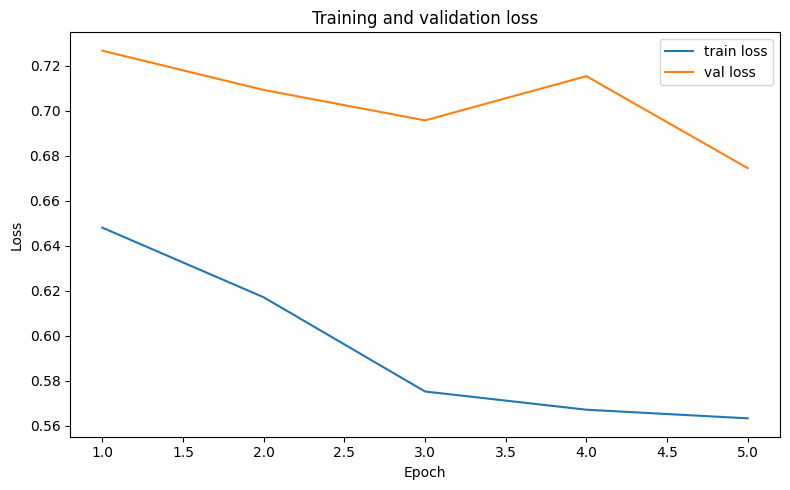

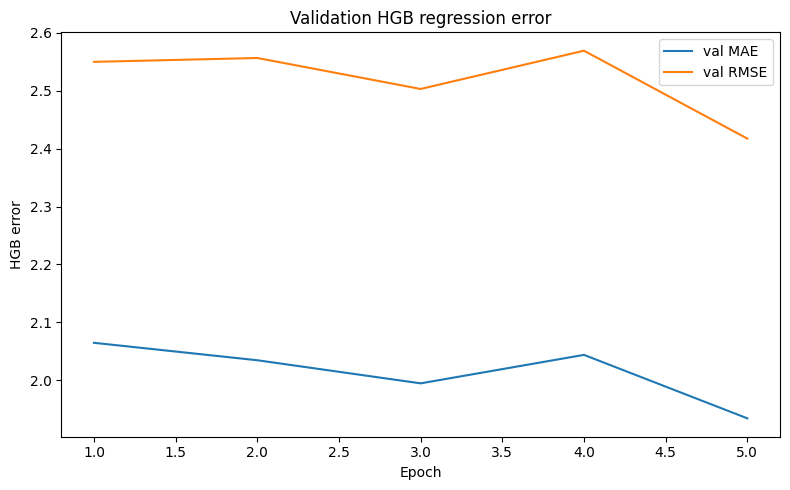

Saved figures to: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/all_usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output_mobilenetv3_lite_outputs


In [14]:

if 'history_df' not in globals() or len(history_df) == 0:
    history_df = pd.read_csv(OUT_DIR / 'training_history.csv')

plt.figure(figsize=(8, 5))
plt.plot(history_df['epoch'], history_df['train_loss'], label='train loss')
plt.plot(history_df['epoch'], history_df['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'training_validation_loss.png', dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df['epoch'], history_df['val_metric_mae'], label='val MAE')
plt.plot(history_df['epoch'], history_df['val_metric_rmse'], label='val RMSE')
plt.xlabel('Epoch')
plt.ylabel('HGB error')
plt.title('Validation HGB regression error')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'validation_regression_error.png', dpi=200)
plt.show()

print('Saved figures to:', OUT_DIR)


## 14. Final evaluation on validation and test set

The checkpoint selected by validation MAE is loaded before final evaluation.


In [15]:

ckpt = torch.load(best_ckpt, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.to(device)
model.eval()
print('Loaded best epoch:', ckpt['epoch'], 'best val MAE:', ckpt['best_val_mae'])

val_pred_img, val_losses = collect_predictions(model, val_loader)
test_pred_img, test_losses = collect_predictions(model, test_loader)

# Choose the anemia probability threshold on validation records only.
# This avoids data leakage because the test set is not used to choose the threshold.
val_pred_rec_for_threshold = aggregate_to_record(val_pred_img, threshold=0.5)
best_cls_threshold, threshold_table = choose_threshold_on_validation(
    val_pred_rec_for_threshold,
    metric=THRESHOLD_TUNING_METRIC
)
threshold_table.to_csv(OUT_DIR / 'validation_threshold_tuning.csv', index=False)
print(f'Classification threshold chosen on validation ({THRESHOLD_TUNING_METRIC}): {best_cls_threshold:.3f}')

val_pred_rec = aggregate_to_record(val_pred_img, threshold=best_cls_threshold)
test_pred_rec = aggregate_to_record(test_pred_img, threshold=best_cls_threshold)

val_metrics = compute_metrics(val_pred_rec)
test_metrics = compute_metrics(test_pred_rec)

metrics_df = pd.DataFrame([
    {'split': 'val', **val_metrics},
    {'split': 'test', **test_metrics},
])
metrics_df.to_csv(OUT_DIR / 'final_record_level_metrics.csv', index=False)
val_pred_img.to_csv(OUT_DIR / 'val_image_level_predictions.csv', index=False)
test_pred_img.to_csv(OUT_DIR / 'test_image_level_predictions.csv', index=False)
val_pred_rec.to_csv(OUT_DIR / 'val_record_level_predictions.csv', index=False)
test_pred_rec.to_csv(OUT_DIR / 'test_record_level_predictions.csv', index=False)

print('Final record-level metrics:')
display(metrics_df)
print('Saved final predictions and metrics to:', OUT_DIR)


Loaded best epoch: 5 best val MAE: 1.9345466971876153
Classification threshold chosen on validation (balanced_accuracy): 0.450
Final record-level metrics:


,split,n_records,mae,rmse,r2,pearson_r,spearman_r,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,val,83,1.934547,2.417186,0.196057,0.446165,0.449181,0.674699,0.681579,0.750000,0.600000,0.666667,0.726316,0.768433
1,test,83,2.050339,2.570227,0.148260,0.404145,0.382383,0.566265,0.587766,0.689655,0.425532,0.526316,0.647754,0.691070


Saved final predictions and metrics to: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/all_usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output_mobilenetv3_lite_outputs


## 15. Performance illustrations

This cell produces the main visual evidence:

- True vs predicted HGB plot
- Residual histogram
- Confusion matrix
- ROC curve
- Anemia-only classification report heatmap: precision, recall, and F1-score

The old test-set precision-recall curve is intentionally removed.


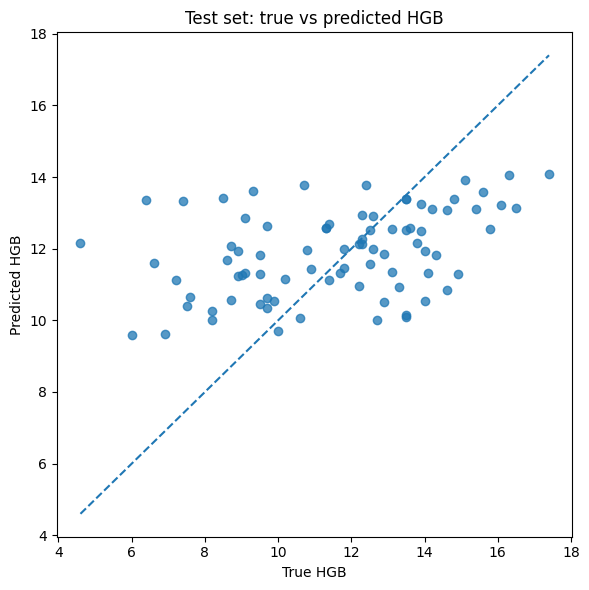

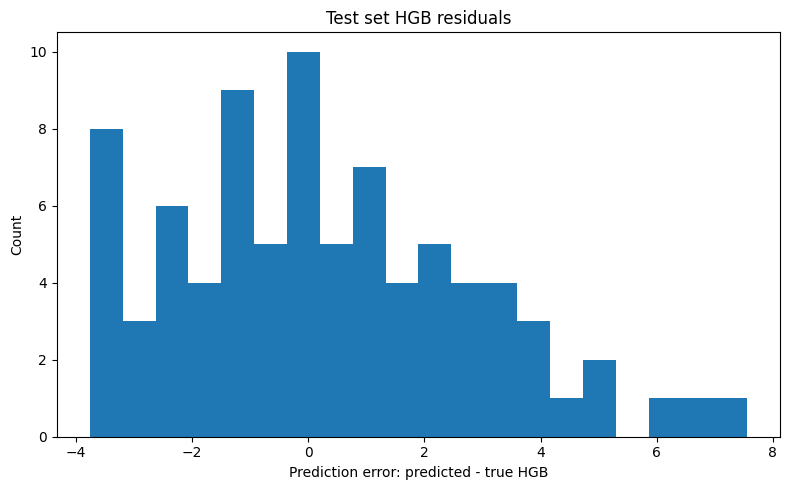

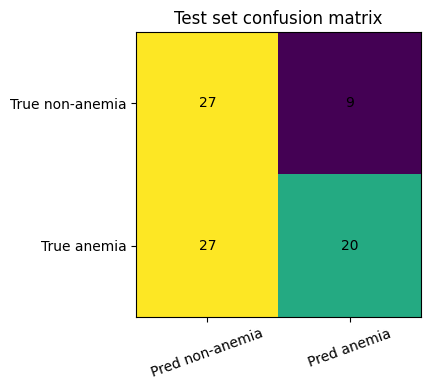

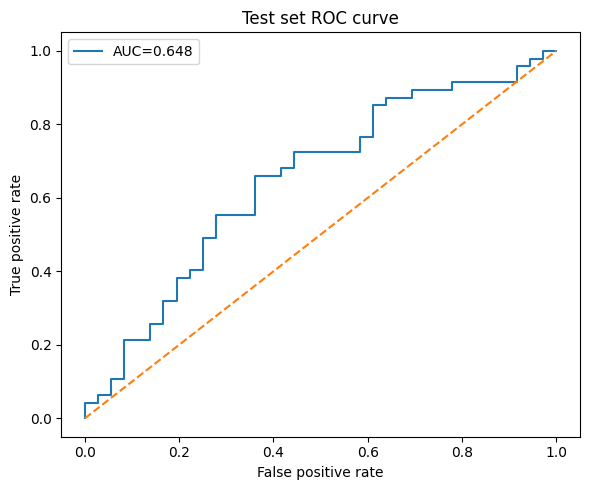

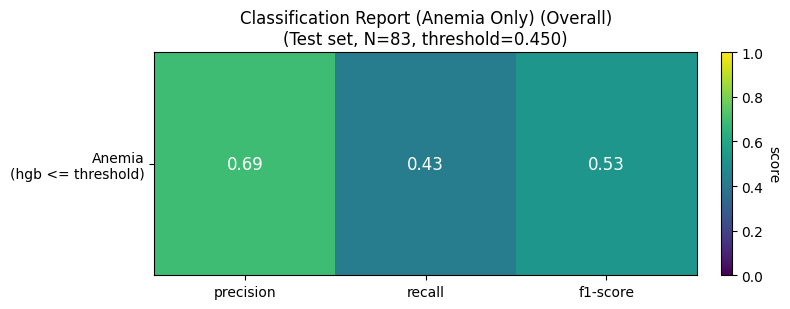

Saved performance figures and anemia-only classification report to: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/all_usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output_mobilenetv3_lite_outputs


In [16]:
# Remove old precision-recall curve output if it exists from a previous run.
old_pr_curve = OUT_DIR / 'test_precision_recall_curve.png'
if old_pr_curve.exists():
    old_pr_curve.unlink()
    print('Removed old PR-curve file:', old_pr_curve)

# True vs predicted HGB.
plt.figure(figsize=(6, 6))
plt.scatter(test_pred_rec['hgb_true'], test_pred_rec['hgb_pred'], alpha=0.75)
lo = min(test_pred_rec['hgb_true'].min(), test_pred_rec['hgb_pred'].min())
hi = max(test_pred_rec['hgb_true'].max(), test_pred_rec['hgb_pred'].max())
plt.plot([lo, hi], [lo, hi], linestyle='--')
plt.xlabel('True HGB')
plt.ylabel('Predicted HGB')
plt.title('Test set: true vs predicted HGB')
plt.tight_layout()
plt.savefig(OUT_DIR / 'test_true_vs_pred_hgb.png', dpi=200)
plt.show()

# Residual histogram.
residual = test_pred_rec['hgb_pred'] - test_pred_rec['hgb_true']
plt.figure(figsize=(8, 5))
plt.hist(residual, bins=20)
plt.xlabel('Prediction error: predicted - true HGB')
plt.ylabel('Count')
plt.title('Test set HGB residuals')
plt.tight_layout()
plt.savefig(OUT_DIR / 'test_hgb_residual_histogram.png', dpi=200)
plt.show()

# Confusion matrix.
cm = confusion_matrix(test_pred_rec['anemia_true'], test_pred_rec['anemia_pred'], labels=[0, 1])
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.xticks([0, 1], ['Pred non-anemia', 'Pred anemia'], rotation=20)
plt.yticks([0, 1], ['True non-anemia', 'True anemia'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')
plt.title('Test set confusion matrix')
plt.tight_layout()
plt.savefig(OUT_DIR / 'test_confusion_matrix.png', dpi=200)
plt.show()

# ROC curve only. The precision-recall curve is intentionally not plotted in this version.
if test_pred_rec['anemia_true'].nunique() == 2:
    fpr, tpr, _ = roc_curve(test_pred_rec['anemia_true'], test_pred_rec['anemia_prob'])
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC={test_metrics['roc_auc']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title('Test set ROC curve')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'test_roc_curve.png', dpi=200)
    plt.show()
else:
    print('ROC skipped because the test set has only one class.')

# Anemia-only classification report heatmap.
# This replaces the previous precision-recall curve figure.
y_true = test_pred_rec['anemia_true'].astype(int).to_numpy()
y_pred = test_pred_rec['anemia_pred'].astype(int).to_numpy()

p, r, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=[1],
    zero_division=0
)

cls_report_anemia = pd.DataFrame(
    {
        'precision': [float(p[0])],
        'recall': [float(r[0])],
        'f1-score': [float(f1[0])],
    },
    index=['Anemia\n(hgb <= threshold)']
)
cls_report_anemia['support'] = int(support[0])
cls_report_anemia.to_csv(OUT_DIR / 'test_classification_report_anemia_only.csv')

# Plot only precision/recall/F1, matching the compact report style.
plot_df = cls_report_anemia[['precision', 'recall', 'f1-score']]
fig, ax = plt.subplots(figsize=(8, 3.2))
im = ax.imshow(plot_df.values, vmin=0, vmax=1, aspect='auto')

ax.set_xticks(np.arange(plot_df.shape[1]))
ax.set_xticklabels(plot_df.columns)
ax.set_yticks(np.arange(plot_df.shape[0]))
ax.set_yticklabels(plot_df.index)

for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        value = plot_df.values[i, j]
        text_color = 'white' if value < 0.70 else 'black'
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', color=text_color, fontsize=12)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel('score', rotation=270, labelpad=12)

plt.title(
    'Classification Report (Anemia Only) (Overall)\n'
    f'(Test set, N={len(test_pred_rec)}, threshold={best_cls_threshold:.3f})'
)
plt.tight_layout()
plt.savefig(OUT_DIR / 'test_classification_report_anemia_only_heatmap.png', dpi=200)
plt.show()

print('Saved performance figures and anemia-only classification report to:', OUT_DIR)


## 16. Subgroup / fairness-style analysis

This does not prove fairness, but it shows whether errors differ strongly across demographic groups.

Reports are computed on record-level predictions, not image-level predictions.


Saved: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/anemia_prediction/all_usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output_mobilenetv3_lite_outputs/test_subgroup_metrics.csv


,group_col,group,n_records,mae,rmse,r2,pearson_r,spearman_r,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,sex_clean,Female,41,1.815719,2.255153,0.021226,0.241095,0.229844,0.536585,0.544686,0.611111,0.478261,0.536585,0.577295,0.626329
1,sex_clean,Male,42,2.279373,2.844331,0.192953,0.486919,0.457567,0.595238,0.631944,0.818182,0.375000,0.514286,0.717593,0.794488
2,race_group,Black,10,2.053680,2.350213,0.477777,0.776908,0.684848,0.700000,0.750000,1.000000,0.500000,0.666667,0.833333,0.910714
3,race_group,Hispanic/Latino,10,2.838820,3.443108,-0.111308,-0.102146,-0.224925,0.300000,0.291667,0.200000,0.250000,0.222222,0.458333,0.440476
4,race_group,White,59,1.986972,2.479238,0.143805,0.428042,0.396206,0.593220,0.630952,0.789474,0.428571,0.555556,0.660714,0.740855
5,ethnicity_clean,HISPANIC,10,2.838820,3.443108,-0.111308,-0.102146,-0.224925,0.300000,0.291667,0.200000,0.250000,0.222222,0.458333,0.440476
6,ethnicity_clean,NON-HISPANIC,72,1.922025,2.409949,0.215436,0.494500,0.455178,0.611111,0.651965,0.826087,0.441860,0.575758,0.704892,0.780699


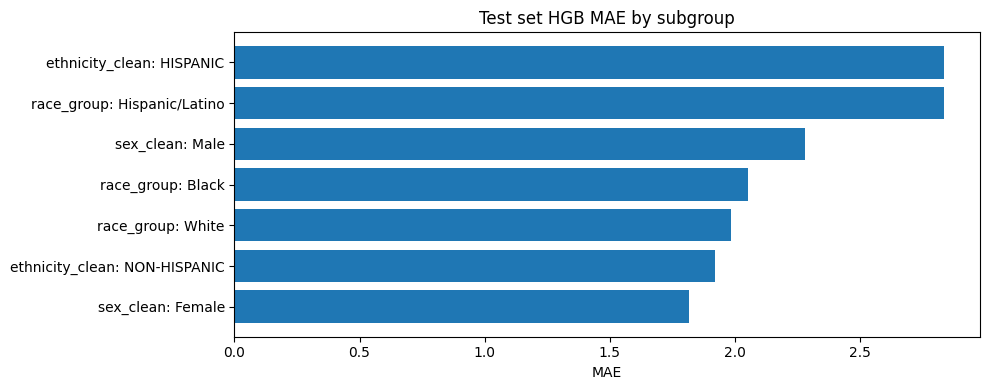

In [17]:

def subgroup_metrics(df, group_col, min_n=5):
    rows = []
    for group, g in df.groupby(group_col):
        if len(g) < min_n:
            continue
        m = compute_metrics(g)
        rows.append({'group_col': group_col, 'group': group, **m})
    return pd.DataFrame(rows)

fairness_parts = []
for col in ['sex_clean', 'race_group', 'ethnicity_clean']:
    fairness_parts.append(subgroup_metrics(test_pred_rec, col, min_n=5))
fairness_df = pd.concat(fairness_parts, ignore_index=True) if fairness_parts else pd.DataFrame()
fairness_df.to_csv(OUT_DIR / 'test_subgroup_metrics.csv', index=False)
print('Saved:', OUT_DIR / 'test_subgroup_metrics.csv')
display(fairness_df)

# Simple bar plot of MAE by subgroup.
if len(fairness_df):
    plot_df = fairness_df.copy()
    plot_df['label'] = plot_df['group_col'] + ': ' + plot_df['group'].astype(str)
    plot_df = plot_df.sort_values('mae')
    plt.figure(figsize=(10, max(4, 0.35 * len(plot_df))))
    plt.barh(plot_df['label'], plot_df['mae'])
    plt.xlabel('MAE')
    plt.title('Test set HGB MAE by subgroup')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'test_subgroup_mae.png', dpi=200)
    plt.show()


## 17. Save a compact model card / run report


In [18]:

run_report = {
    'task': 'Anemia prediction from preprocessed nail images — MacBook Lite',
    'model': 'MobileNetV3-Small frozen backbone + demographics intermediate fusion + regression/classification heads',
    'no_ita_skin_tone_input': True,
    'data_split': {
        'unit': 'record_id / patient',
        'test_size': TEST_SIZE,
        'val_size': VAL_SIZE,
        'patient_overlap_check_passed': True,
        'hash_leakage_check_run': RUN_HASH_LEAKAGE_CHECK,
        'macbook_lite': True,
        'image_size': IMAGE_SIZE,
        'batch_size': BATCH_SIZE,
        'device': str(device),
    },
    'csv_shapes': {
        'FileDirectory.csv': list(filedir_raw.shape),
        'PredictingAnemiaInCo-CJStudyData_DATA_2023-07-12_0653.csv': list(lab_raw.shape),
        'Race and gender file 070425.csv': list(demo_raw.shape),
    },
    'dataset_after_cleaning': {
        'records_with_matched_images': int(image_df_fe['record_id'].nunique()),
        'image_rows_with_matched_paths': int(len(image_df_fe)),
        'train_records': int(train_df['record_id'].nunique()),
        'val_records': int(val_df['record_id'].nunique()),
        'test_records': int(test_df['record_id'].nunique()),
        'train_images': int(len(train_df)),
        'val_images': int(len(val_df)),
        'test_images': int(len(test_df)),
    },
    'preprocessing': preprocess_info,
    'best_epoch': int(ckpt['epoch']),
    'classification_threshold_used': float(best_cls_threshold) if 'best_cls_threshold' in globals() else 0.5,
    'threshold_tuning_metric': THRESHOLD_TUNING_METRIC,
    'final_metrics': metrics_df.to_dict(orient='records'),
}
with open(OUT_DIR / 'run_report.json', 'w') as f:
    json.dump(run_report, f, indent=2)
print(json.dumps(run_report, indent=2)[:3000])
print('Saved:', OUT_DIR / 'run_report.json')


{
  "task": "Anemia prediction from preprocessed nail images \u2014 MacBook Lite",
  "model": "MobileNetV3-Small frozen backbone + demographics intermediate fusion + regression/classification heads",
  "no_ita_skin_tone_input": true,
  "data_split": {
    "unit": "record_id / patient",
    "test_size": 0.1,
    "val_size": 0.1,
    "patient_overlap_check_passed": true,
    "hash_leakage_check_run": false,
    "macbook_lite": true,
    "image_size": 128,
    "batch_size": 4,
    "device": "mps"
  },
  "csv_shapes": {
    "FileDirectory.csv": [
      8929,
      10
    ],
    "PredictingAnemiaInCo-CJStudyData_DATA_2023-07-12_0653.csv": [
      1151,
      5
    ],
    "Race and gender file 070425.csv": [
      1493,
      4
    ]
  },
  "dataset_after_cleaning": {
    "records_with_matched_images": 830,
    "image_rows_with_matched_paths": 3422,
    "train_records": 664,
    "val_records": 83,
    "test_records": 83,
    "train_images": 2745,
    "val_images": 338,
    "test_images": 339

## 18. Inference helper for new images

Use this after training to predict HGB/anemia for new preprocessed nail image(s).

For multiple nail crops from the same person, pass all image paths and the function will average predictions.


In [19]:

def build_demo_vector_for_one(age, sex='Not Sure', race_group='Unknown', ethnicity_clean='Unknown'):
    row = pd.DataFrame([{
        'age_num': age,
        'sex_clean': normalize_sex(sex),
        'race_group': clean_text(race_group),
        'ethnicity_clean': clean_text(ethnicity_clean),
    }])
    # Match expected columns used by the encoder.
    for col in cat_cols:
        if col not in row.columns:
            row[col] = 'Unknown'
    age_series = pd.to_numeric(row['age_num'], errors='coerce').fillna(age_median).astype(float)
    row['age_z'] = ((age_series - age_mean) / age_std).round(1)
    cat = ohe.transform(row[cat_cols].fillna('Unknown'))
    try:
        cat_names = ohe.get_feature_names_out(cat_cols).tolist()
    except Exception:
        cat_names = [f'cat_{i}' for i in range(cat.shape[1])]
    cat_df = pd.DataFrame(cat, columns=cat_names, index=row.index)
    row = pd.concat([row, cat_df], axis=1)
    return torch.tensor(row[demo_feature_cols].astype(float).values, dtype=torch.float32)


def predict_person_images(image_paths, age, sex='Not Sure', race_group='Unknown', ethnicity_clean='Unknown'):
    model.eval()
    demo = build_demo_vector_for_one(age, sex, race_group, ethnicity_clean).to(device)
    preds_hgb = []
    preds_prob = []
    with torch.no_grad():
        for p in image_paths:
            img = Image.open(p).convert('RGB')
            img = eval_transform(img).unsqueeze(0).to(device)
            pred_z, logit = model(img, demo)
            pred_hgb = float(pred_z.cpu().numpy().reshape(-1)[0] * hgb_std + hgb_mean)
            prob = float(torch.sigmoid(logit).cpu().numpy().reshape(-1)[0])
            preds_hgb.append(pred_hgb)
            preds_prob.append(prob)
    return {
        'hgb_pred_mean': float(np.mean(preds_hgb)),
        'hgb_pred_per_image': preds_hgb,
        'anemia_prob_mean': float(np.mean(preds_prob)),
        'anemia_pred': int(np.mean(preds_prob) >= 0.5),
    }

# Example after training:
# result = predict_person_images(['/path/to/nail1.png', '/path/to/nail2.png'], age=33, sex='M')
# result


# Done

After running all cells, the important outputs are in `OUT_DIR`:

- `best_mobilenetv3small_fusion_macbook_lite_no_leakage.pt`
- `final_record_level_metrics.csv`
- `test_record_level_predictions.csv`
- `test_true_vs_pred_hgb.png`
- `test_confusion_matrix.png`
- `test_roc_curve.png`
- `test_classification_report_anemia_only_heatmap.png`
- `test_classification_report_anemia_only.csv`
- `test_subgroup_metrics.csv`
- `run_report.json`

The patient-level split/leakage check still runs. The optional exact-image hash leakage check is off by default to reduce MacBook heat; set `RUN_HASH_LEAKAGE_CHECK = True` once for a final verification run.
